In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.initializers import HeNormal

tf.random.set_seed(42)
np.random.seed(42)

In [36]:
df = pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [37]:
df.shape

(500, 9)

In [38]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [40]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

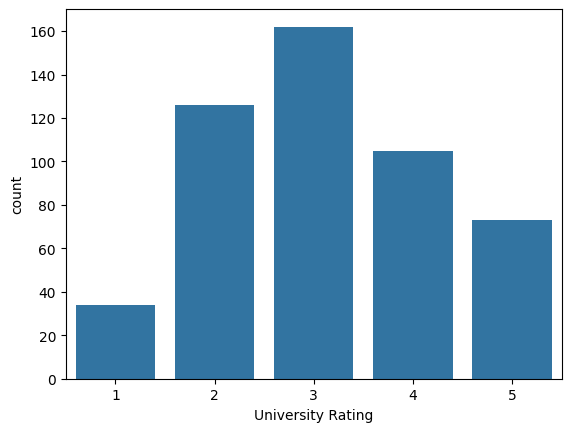

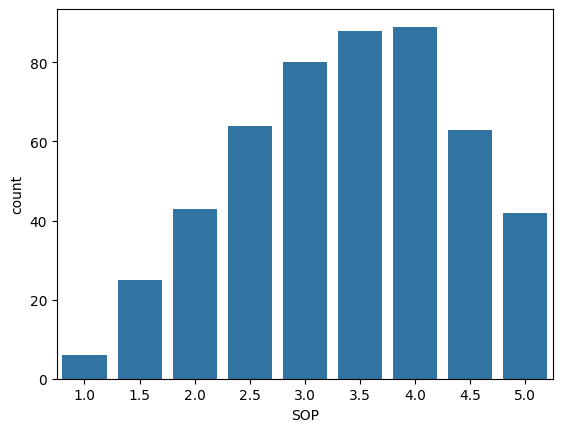

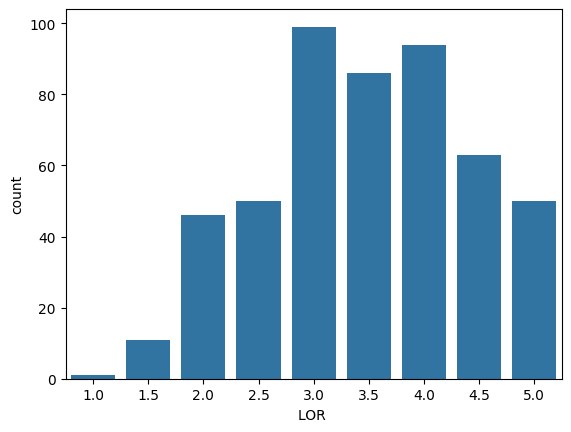

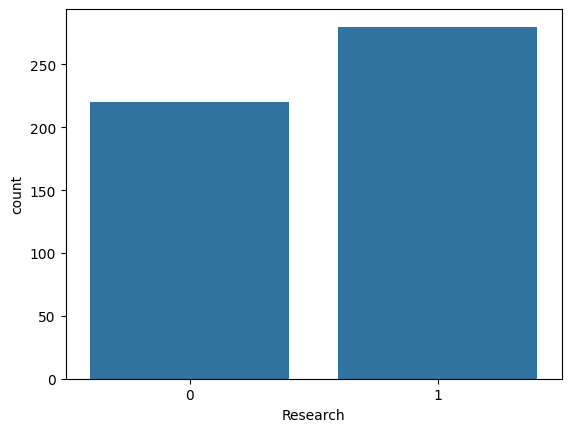

In [43]:
discrete_columns = ['University Rating', 'SOP', 'LOR ', 'Research']
for col in discrete_columns:
    sns.countplot(x = df[col])
    plt.show()
   

In [44]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

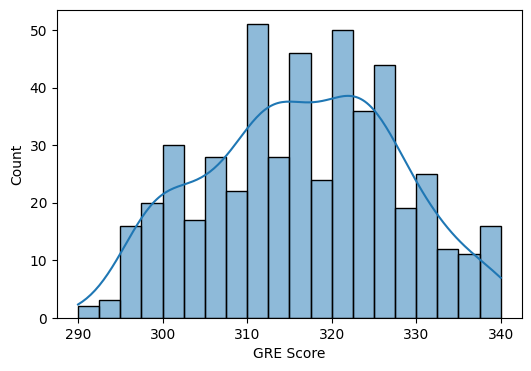

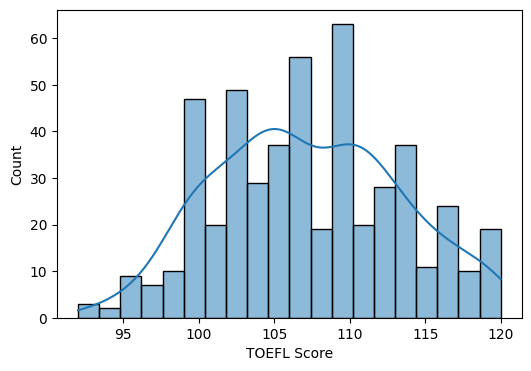

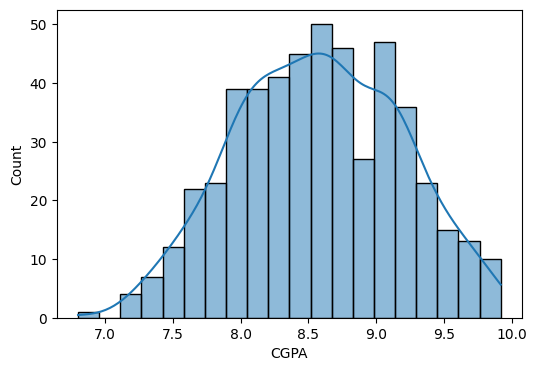

In [45]:
continuous_columns = ['GRE Score', 'TOEFL Score', 'CGPA']
for col in continuous_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)

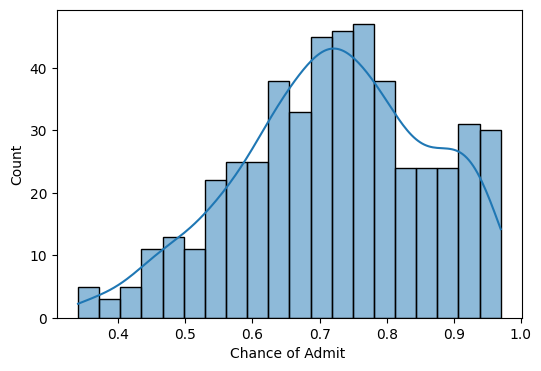

In [46]:
target_column = ['Chance of Admit ']
for col in target_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)

In [47]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

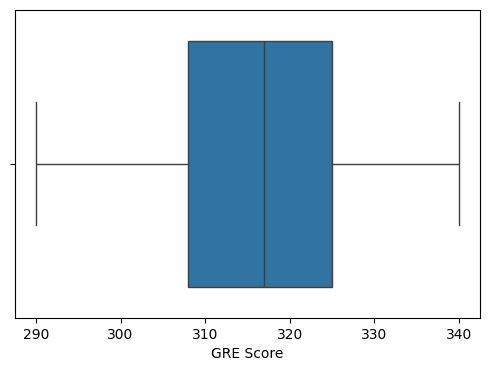

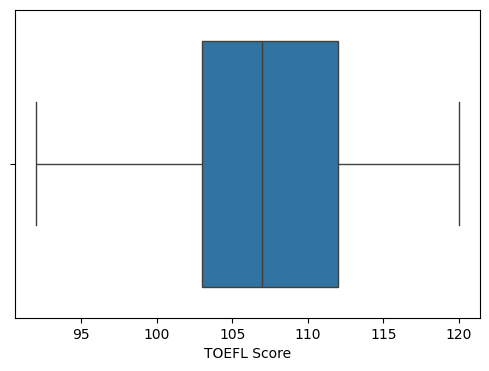

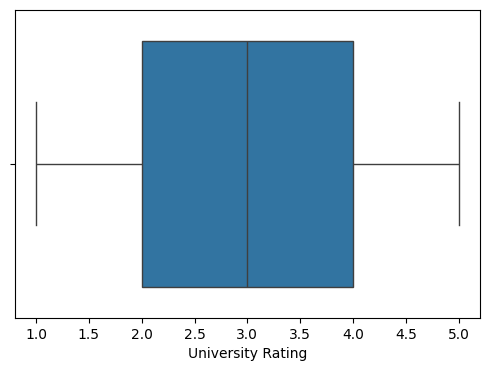

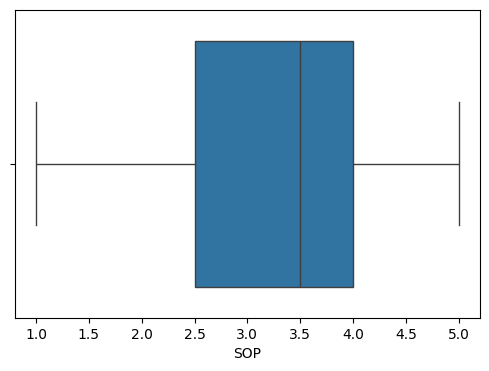

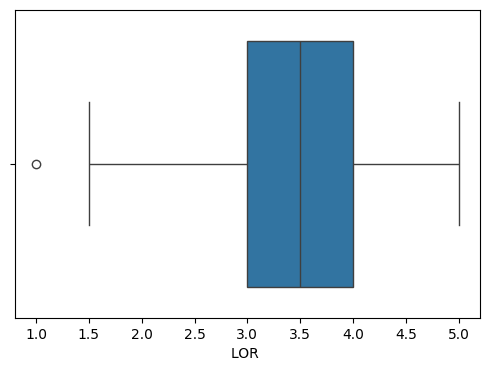

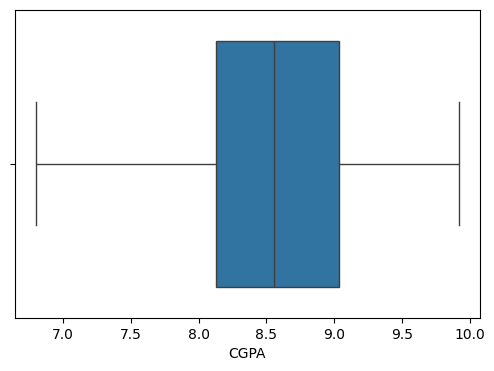

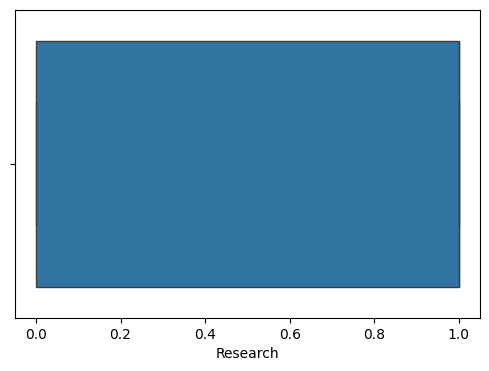

In [48]:
numeric_columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP','LOR ', 'CGPA', 'Research']
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

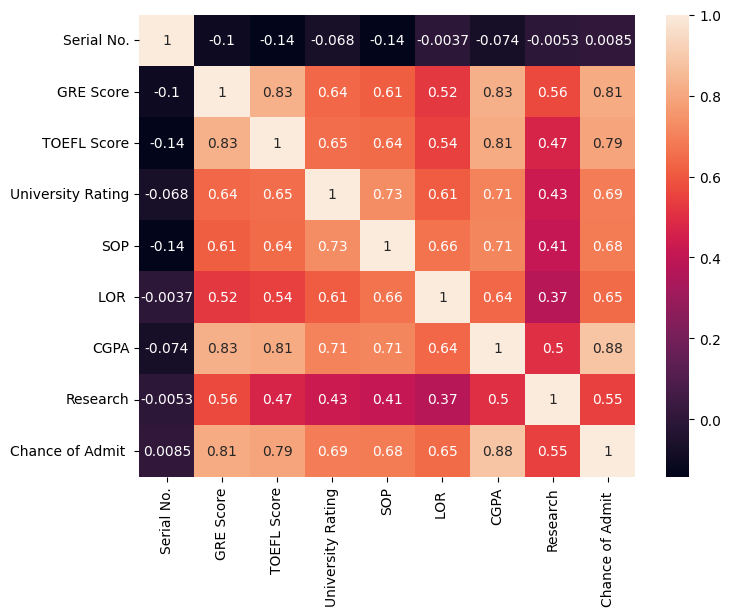

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [50]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [51]:
from scipy.stats import pearsonr

In [52]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------
# List of features to check against target
selected_features = [
    'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
    'LOR ', 'CGPA', 'Research'
]

correlations = {
    feature: pearsonr(df[feature], df['Chance of Admit '])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
5,CGPA,0.882413
0,GRE Score,0.810351
1,TOEFL Score,0.792228
2,University Rating,0.690132
3,SOP,0.684137
4,LOR,0.645365
6,Research,0.545871


In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df['Chance of Admit _bin'] = pd.qcut(df['Chance of Admit '].rank(method='first'), q=4, labels=False)
chi2_results = {}

for col in discrete_columns:
    contingency = pd.crosstab(df[col], df['Chance of Admit _bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
University Rating,349.251927,0.0,Reject Null (Keep Feature)
SOP,354.009266,0.0,Reject Null (Keep Feature)
LOR,255.497977,0.0,Reject Null (Keep Feature)
Research,164.090909,0.0,Reject Null (Keep Feature)


In [54]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit ', 'Chance of Admit _bin'],
      dtype='object')

In [55]:
final_df = df[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit ']]

##  Baseline Model (original architecture, for comparison)

This reproduces the original notebook's simple network — 2 hidden layers of 7 neurons each, trained for a fixed 100 epochs with no regularization — so we have a fair "before" number to compare the optimized model against.

In [56]:
final_df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [57]:
X = final_df.iloc[:,:-1]
y = final_df.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [58]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
238,310,104,3,2.0,3.5,8.37,0
438,318,110,1,2.5,3.5,8.54,1
475,300,101,3,3.5,2.5,7.88,0
58,300,99,1,3.0,2.0,6.80,1
380,322,104,3,3.5,4.0,8.84,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [59]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
X_train_scaled

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]])

In [61]:
baseline_model = Sequential([
    Dense(7, activation='relu', input_dim=7),
    Dense(7, activation='relu'),
    Dense(1, activation='linear')   # linear output -> required for regression
])

baseline_model.compile(loss='mse', optimizer='adam')

baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

baseline_pred = baseline_model.predict(X_test_scaled, verbose=0)
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"Baseline Test R²: {baseline_r2:.4f}")

Baseline Test R²: 0.7458


##  Optimized Neural Network — architecture and why each choice was made

| Parameter | Choice | Why |
|---|---|---|
| Hidden layers | 3 layers (64 → 32 → 16) | Gradually narrowing ("funnel") architecture lets the network learn broad patterns first, then refine them, without being so large that it overfits this small dataset (~500 rows). |
| Activation | `relu` on hidden layers | Fast to compute, avoids vanishing gradients that `sigmoid`/`tanh` suffer from in deeper nets. |
| Output activation | `linear` (none) | Required for regression — the target isn't a class probability from softmax, it's a real number. |
| Weight initialization | `HeNormal` | Designed specifically to pair with ReLU; keeps the variance of activations stable across layers so training starts well-conditioned. |
| Batch Normalization | after each hidden layer | Normalizes activations between layers, which speeds up convergence and adds a small regularizing effect. |
| Dropout | 0.2 after first two hidden layers | Randomly "turns off" 20% of neurons each step during training, forcing the network to not over-rely on any single neuron — reduces overfitting. |
| Optimizer | `Adam` with `learning_rate=0.001` | Adam adapts the learning rate per-parameter, which generally converges faster and more reliably than plain SGD, especially with limited tuning time. |
| Loss function | `mse` (Mean Squared Error) | Standard regression loss — penalizes larger errors more heavily, pushing the model to avoid big mistakes. |
| Early stopping | `patience=15`, restore best weights | Stops training once validation loss stops improving, preventing overfitting from training too long, and keeps the best-performing weights rather than the final epoch's. |
| LR reduction on plateau | factor=0.5, patience=7 | If validation loss stalls, the learning rate is halved — lets the model take a bigger step early on and smaller, more precise steps once it's close to a good solution. |
| Epochs | up to 300 (early stopping will likely stop earlier) | We let early stopping decide the actual number rather than guessing a fixed value. |


In [62]:
optimized_model = Sequential([
    Dense(64, activation='relu', kernel_initializer=HeNormal(), input_dim=7),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu', kernel_initializer=HeNormal()),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu', kernel_initializer=HeNormal()),
    BatchNormalization(),

    Dense(1, activation='linear')   # linear output for regression
])

optimized_model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

optimized_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,361 (13.13 KB)

 Non-trainable params: 224 (896.00 B)

### Optimized Neural Network => Callbacks: Early Stopping + Learning Rate Reduction

Rather than guessing a fixed number of epochs, we let the training process
adapt itself:

- **EarlyStopping** watches validation loss and stops training once it stops
  improving for `patience` epochs, restoring the best-performing weights seen
  so far (prevents overfitting from training too long).
- **ReduceLROnPlateau** halves the learning rate if validation loss plateaus,
  allowing fine-grained convergence once the model is close to a good
  solution.


In [63]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6
)

optimized_history = optimized_model.fit(
    X_train_scaled, y_train,
    epochs=300,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

print(f"Training stopped after {len(optimized_history.history['loss'])} epochs (early stopping).")


Training stopped after 207 epochs (early stopping).


##  Training Curves — Baseline vs. Optimized

Plotting training vs. validation loss for both models shows whether each one
is overfitting (training loss much lower than validation loss) or still
improving (both curves still decreasing when training stopped).

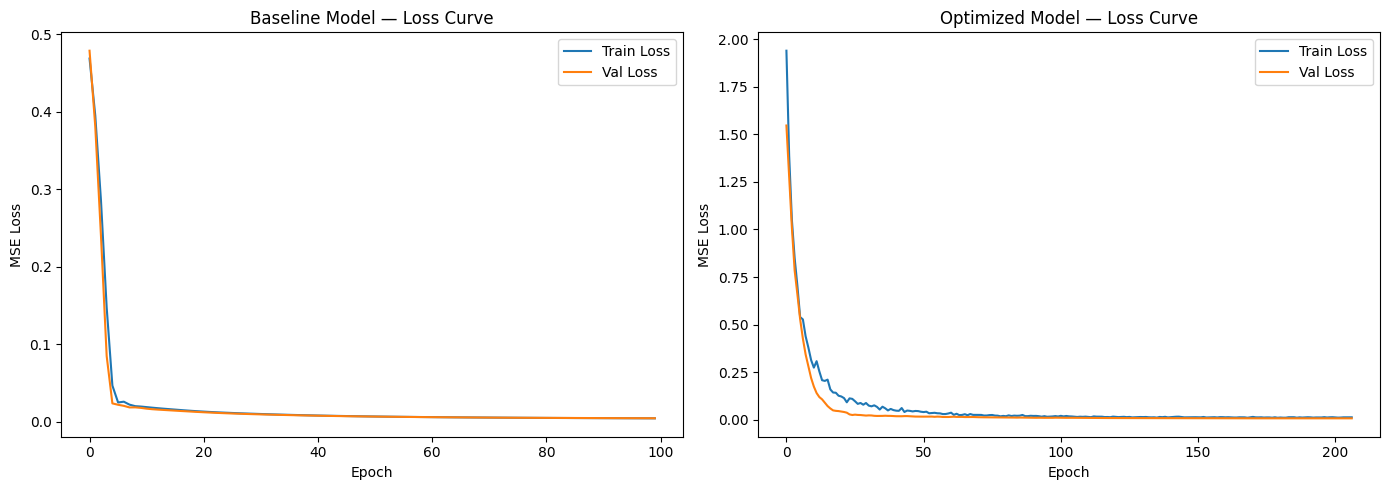

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'], label='Train Loss')
axes[0].plot(baseline_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Baseline Model — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(optimized_history.history['loss'], label='Train Loss')
axes[1].plot(optimized_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Optimized Model — Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


##  Evaluate on the Test Set

For regression we look at three complementary metrics:

- **R² (coefficient of determination)** — proportion of variance in the
  target explained by the model. 1.0 is a perfect fit, 0 means no better
  than predicting the mean every time.
- **MAE (Mean Absolute Error)** — average absolute difference between
  predicted and actual chance of admission, in the same units as the target
  (e.g. an MAE of 0.05 means predictions are off by ~5 percentage points on
  average).
- **RMSE (Root Mean Squared Error)** — similar to MAE but penalizes larger
  errors more heavily, useful for spotting models that occasionally make big
  mistakes.

We also clip predictions to `[0, 1]` since `Chance of Admit` can never
logically fall outside that range, even if the raw network output does by a
tiny amount.


In [68]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [69]:
optimized_pred = optimized_model.predict(X_test_scaled, verbose=0)
optimized_pred_clipped = np.clip(optimized_pred, 0, 1)

def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:>20} | R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return r2, mae, rmse

print("=" * 70)
evaluate(y_test, baseline_pred, "Baseline ANN")
evaluate(y_test, optimized_pred_clipped, "Optimized ANN")
print("=" * 70)


        Baseline ANN | R²: 0.7458 | MAE: 0.0498 | RMSE: 0.0701
       Optimized ANN | R²: 0.7306 | MAE: 0.0521 | RMSE: 0.0721


###  Predicted vs. Actual

A scatter plot of predicted vs. actual values, with a diagonal reference
line, is one of the clearest ways to visualize regression performance —
points closer to the diagonal are better predictions.


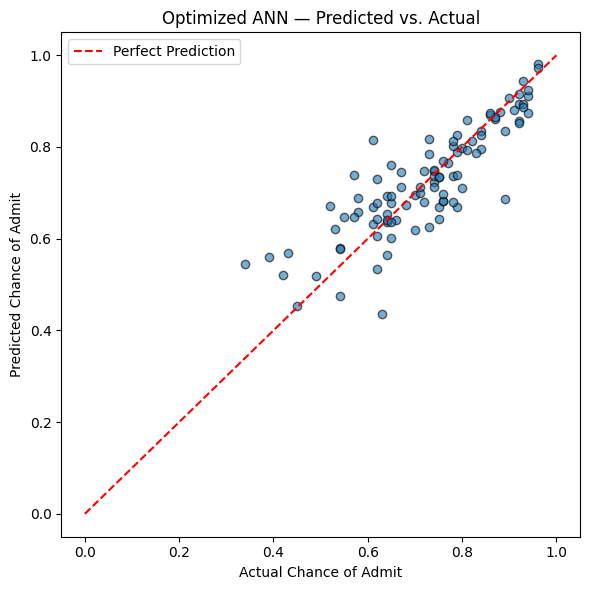

In [70]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, optimized_pred_clipped, alpha=0.6, edgecolor='k')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Optimized ANN — Predicted vs. Actual')
plt.legend()
plt.tight_layout()
plt.show()


##  Which features matter most to the optimized model?

Neural networks don't expose feature importances directly (unlike tree
models), so we estimate it with **permutation importance**: shuffle one
feature at a time in the test set and measure how much the model's R² drops.
A larger drop means the model relies on that feature more heavily.


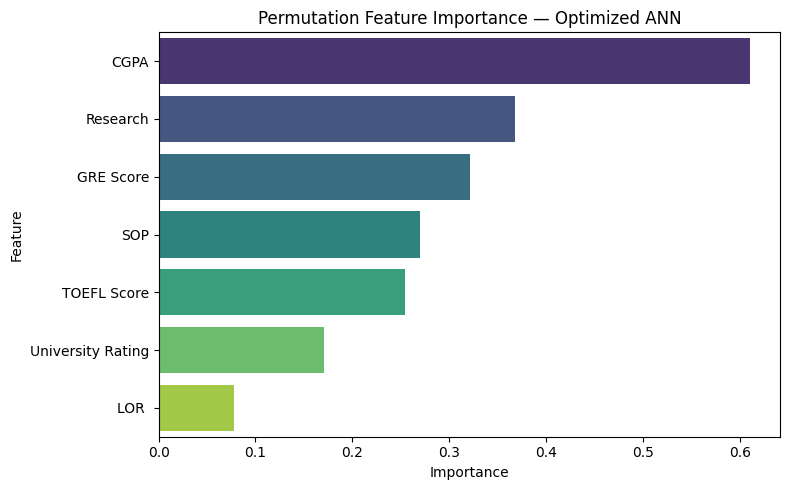

,Feature,Importance
5,CGPA,0.611119
6,Research,0.367759
0,GRE Score,0.321934
3,SOP,0.270185
1,TOEFL Score,0.254296
2,University Rating,0.171259
4,LOR,0.077660


In [71]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Wrap the Keras model so sklearn's permutation_importance can call it
class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return self.model.predict(X, verbose=0).ravel()

wrapped_model = KerasWrapper(optimized_model)

perm_result = permutation_importance(
    wrapped_model, X_test_scaled, y_test,
    scoring='r2', n_repeats=10, random_state=42
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Permutation Feature Importance — Optimized ANN')
plt.tight_layout()
plt.show()

importance_df


##  Summary

- Switched scaling from `MinMaxScaler` to `StandardScaler`, which pairs
  better with ReLU + Adam.
- Deepened and widened the network (64 → 32 → 16) with a funnel shape,
  using **He initialization** to match the ReLU activations.
- Added **Batch Normalization** and **Dropout** to stabilize training and
  reduce overfitting.
- Replaced a fixed 100-epoch schedule with **EarlyStopping** and
  **ReduceLROnPlateau**, so the model trains exactly as long as it's still
  improving and fine-tunes its learning rate automatically.
- Evaluated with **R², MAE, and RMSE** (not just R²) for a fuller picture of
  error magnitude, and visualized predictions against actual values.
- Estimated **feature importance** via permutation, since ANNs don't expose
  it natively the way tree-based models do.

### Ideas to push accuracy further
- **Hyperparameter search** (Keras Tuner or Optuna) over layer sizes,
  dropout rate, and learning rate rather than hand-picked values used here.
- **K-fold cross-validation** instead of a single train/test split, since the
  dataset is small (~500 rows) and results can vary with the split.
- **Feature engineering** — e.g. interaction terms like `CGPA × Research`,
  or polynomial features on the strongest correlated variables.
- **Ensembling** — average predictions from the ANN with a gradient boosting
  regressor (e.g. `XGBRegressor`), which often outperforms a single model on
  small tabular datasets like this one.
